# GIN neighborhood perturbation analysis

This notebook runs the **neighborhood perturbation analysis** using
`compute_perturbation_influence_maps()` for **GINCurvature** models:

- **with** global features
- **without** global features

at depths:

- **2**
- **4**
- **6**

For each configuration, it:
1. loads and prepares the dataset using the updated metadata conventions,
2. trains a GIN model,
3. builds and samples validation ego-subgraphs,
4. computes perturbation influence maps,
5. plots the results,
6. saves the experiment outputs.


In [21]:

import copy
import json
import math
import pickle
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import sys

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"
RESULTS_ROOT = PROJECT_ROOT / "results_experiments" / "ablation_analysis_global"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("RESULTS_ROOT =", RESULTS_ROOT)
print("torch.cuda.is_available() =", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
RESULTS_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis_global
torch.cuda.is_available() = True
device = cuda


In [ ]:

# ----------------------------
# Editable experiment settings
# ----------------------------
DATA_SUBDIR = "smooth"

COMPLEXITY_THRESHOLD = 2.0

VAL_FRAC = 0.10
SPLIT_SEED = 0

FEATURE_VARIANTS = {
    "no_global": False,
    "with_global": True,
}

DEPTHS = [2, 4]

HIDDEN_DIM = 4 * 64
DROPOUT = 0.10
NORM = "batch"
RESIDUAL = True

LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4

EDGE_LOSS_WEIGHT = 0.2
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

MAX_SUBGRAPHS = 2500
MIN_CENTER_COUNT = 40
MIN_PAIR_COUNT = 25
SUBGRAPH_SEED = 0
PERTURB_BATCH_SIZE = 128

SAVE_GROUP = "gin_perturbation_analysis"


In [23]:

from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import (
    attach_metadata_to_graphs,
    ensure_metadata_keys,
    infer_global_dim,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    promote_metadata_to_graph_tensors,
    snapshot_graph_metadata,
    strip_graph_metadata,
)
from src.data.preprocessing import subtract_organoid_mean_curvature, robust_zscore_organoid_targets
from src.data.splits import (
    standardize_graph_global_features,
    standardize_graph_targets,
    train_val_split_graphs,
)
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term
from src.inference.predict import predict_targets

from src.data.subgraphs import build_ego_subgraphs_for_dataset
from src.data.subgraph_sampling import sample_subgraphs_coverage, print_sampling_summary
from src.analysis.perturbation import compute_perturbation_influence_maps
from src.plotting.influence_maps import plot_influence_heatmap, plot_influence_center_resolved


In [ ]:
data_dir = PROJECT_ROOT / "training_data" / "smooth_cryptdist"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attach_metadata_to_graphs(graphs, meta)

marker_names = load_marker_names_from_dir(data_dir)

Loaded 1135 graphs; skipped 0.
Loaded 1135 organoids.
Attached metadata to 1135/1135 graphs.


In [ ]:
from src.data.metadata import print_graph_and_metadata_fields

print_graph_and_metadata_fields(graphs)

After complexity filter: 629 organoids.


In [ ]:
from src.data.metadata import fill_missing_metadata_for_group

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=2.1,
    dataset="20251201",
    timepoint="day4p5",
)

In [ ]:
from src.data.metadata import filter_graphs_by_numeric_metadata

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=2.0,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

from src.data.metadata import filter_graphs_by_sphericity

graphs = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=0.915,
    print_summary=True,
)


In [ ]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

graphs = add_log_metadata_features(graphs, inplace=False)

graphs = promote_metadata_to_graph_tensors(
    graphs,
    field_specs=[
        {
            "meta_keys": [
                "log_surface_area",
                "log_volume",
                "log_volume_over_area",
                "log_num_cells",
            ],
            "attr_name": "global_feat",
            "kind": "graph_vector",
            "dtype": torch.float32,
        },
    ],
    inplace=False,
)

Added tensorized metadata fields to graphs.


In [ ]:
from src.data.splits import train_val_split_graphs


g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=0.1,
    seed=None,
)

print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

Split -> train: 566 | val: 63
n_markers = 7


In [28]:

def prepare_graph_variant(train_graphs, val_graphs, *, use_global_features: bool):
    g_train = copy.deepcopy(train_graphs)
    g_val = copy.deepcopy(val_graphs)

    if not use_global_features:
        for g in g_train:
            if hasattr(g, "global_feat"):
                delattr(g, "global_feat")
        for g in g_val:
            if hasattr(g, "global_feat"):
                delattr(g, "global_feat")

    val_meta_lookup = snapshot_graph_metadata(g_val)

    g_train = strip_graph_metadata(g_train, inplace=False)
    g_val = strip_graph_metadata(g_val, inplace=False)

    center, scale = standardize_graph_targets(g_train, g_val, robust=True)

    center_global, scale_global = None, None
    if use_global_features:
        center_global, scale_global = standardize_graph_global_features(
            g_train,
            g_val,
            attr_name="global_feat",
            robust=False,
        )

    return {
        "g_train": g_train,
        "g_val": g_val,
        "center": center,
        "scale": scale,
        "center_global": center_global,
        "scale_global": scale_global,
        "val_meta_lookup": val_meta_lookup,
    }


def make_gin_model(g_train, depth):
    n_markers = int(g_train[0].x.size(1))
    global_dim = infer_global_dim(g_train)

    model = GINCurvature(
        n_markers=n_markers,
        global_dim=global_dim,
        hidden_dim=HIDDEN_DIM,
        num_layers=depth,
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
    )
    return model


def make_train_config():
    aux_losses = [
        WeightedLossTerm(
            name="edge",
            fn=edge_loss_term,
            weight=EDGE_LOSS_WEIGHT,
            params=EDGE_LOSS_PARAMS,
        ),
    ]

    return TrainConfig(
        lr=LR,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        num_workers=NUM_WORKERS,
        aux_losses=aux_losses,
    )


In [29]:

variant_data = {
    variant_name: prepare_graph_variant(
        base_train,
        base_val,
        use_global_features=use_global_features,
    )
    for variant_name, use_global_features in FEATURE_VARIANTS.items()
}

for variant_name, pack in variant_data.items():
    gd = infer_global_dim(pack["g_train"])
    print(
        f"{variant_name:>11s} | "
        f"train={len(pack['g_train'])} | val={len(pack['g_val'])} | "
        f"global_dim={gd}"
    )


  no_global | train=566 | val=63 | global_dim=0
with_global | train=566 | val=63 | global_dim=4


In [30]:

trained_models = {}
training_logs = {}
prediction_summaries = {}

for variant_name, pack in variant_data.items():
    for depth in DEPTHS:
        family_key = f"GIN | {variant_name} | depth={depth}"
        print("\n" + "=" * 80)
        print("Training", family_key)

        model = make_gin_model(pack["g_train"], depth=depth)
        cfg = make_train_config()

        model, metrics, history = train(model, pack["g_train"], pack["g_val"], cfg)

        trained_models[family_key] = model
        training_logs[family_key] = {
            "metrics": metrics,
            "history": history,
            "variant_name": variant_name,
            "depth": depth,
        }

        y_true, y_pred, X = predict_targets(
            pack["g_val"],
            model,
            batch_size=BATCH_SIZE,
        )

        prediction_summaries[family_key] = {
            "y_true_shape": np.shape(y_true),
            "y_pred_shape": np.shape(y_pred),
            "X_shape": np.shape(X) if X is not None else None,
            "variant_name": variant_name,
            "depth": depth,
        }

print("\nFinished training", len(trained_models), "models.")



Training GIN | no_global | depth=2
epoch 001 | train loss 1.1964 mae 1.0066 | val loss 0.8725 mae 0.9469
epoch 002 | train loss 0.9049 mae 0.9662 | val loss 0.8258 mae 0.9240
epoch 003 | train loss 0.8620 mae 0.9529 | val loss 0.8281 mae 0.9320
epoch 004 | train loss 0.8546 mae 0.9452 | val loss 0.7821 mae 0.9168
epoch 005 | train loss 0.8432 mae 0.9364 | val loss 0.7913 mae 0.9322
epoch 006 | train loss 0.8332 mae 0.9369 | val loss 0.7830 mae 0.9325
epoch 007 | train loss 0.8286 mae 0.9405 | val loss 0.7626 mae 0.9146
epoch 008 | train loss 0.8243 mae 0.9311 | val loss 0.7775 mae 0.9323
epoch 009 | train loss 0.8162 mae 0.9284 | val loss 0.7760 mae 0.9294
epoch 010 | train loss 0.8141 mae 0.9282 | val loss 0.7553 mae 0.9100
epoch 011 | train loss 0.8100 mae 0.9232 | val loss 0.7763 mae 0.9309
epoch 012 | train loss 0.8069 mae 0.9224 | val loss 0.7470 mae 0.9030
epoch 013 | train loss 0.8059 mae 0.9250 | val loss 0.7623 mae 0.9189
epoch 014 | train loss 0.8012 mae 0.9203 | val loss 0.

## Neighborhood perturbation analysis

In [31]:

perturbation_results = {}
sampling_results = {}
sampled_val_subgraphs_by_key = {}

for family_key, model in trained_models.items():
    parts = family_key.split(" | ")
    _, variant_name, depth_part = parts
    depth = int(depth_part.split("=")[1])

    pack = variant_data[variant_name]

    print("\n" + "=" * 80)
    print("Preparing perturbation analysis for", family_key)

    val_subgraphs = build_ego_subgraphs_for_dataset(
        pack["g_val"],
        num_hops=depth,
        max_centers_per_graph=None,
        seed=SUBGRAPH_SEED,
    )

    sampled_val_subgraphs, sample_info = sample_subgraphs_coverage(
        val_subgraphs,
        marker_names=marker_names,
        k_hops=depth,
        max_subgraphs=MAX_SUBGRAPHS,
        min_center_count=MIN_CENTER_COUNT,
        min_pair_count=MIN_PAIR_COUNT,
        seed=SUBGRAPH_SEED,
    )

    sampled_val_subgraphs_by_key[family_key] = sampled_val_subgraphs
    sampling_results[family_key] = sample_info

    print_sampling_summary(sample_info, marker_names)

    res = compute_perturbation_influence_maps(
        subgraphs=sampled_val_subgraphs,
        model=model,
        marker_names=marker_names,
        k_hops=depth,
        mode="single",
        max_subgraphs=None,
        batch_size=PERTURB_BATCH_SIZE,
    )

    perturbation_results[family_key] = {
        "result": res,
        "variant_name": variant_name,
        "depth": depth,
        "n_sampled_subgraphs": len(sampled_val_subgraphs),
    }

print("\nComputed perturbation results for", len(perturbation_results), "models.")



Preparing perturbation analysis for GIN | no_global | depth=2
Selected 2500 / 28292 subgraphs

Center coverage:
Agr2          covered= 211  target=  40  available=1715  OK
AldoB         covered=1111  target=  40  available=12235  OK
Chroma        covered=  57  target=  40  available=  97  OK
KI67          covered= 717  target=  40  available=7879  OK
LGR5          covered= 496  target=  40  available=4820  OK
Lysozyme      covered= 128  target=  40  available= 860  OK
Serotonin     covered=  65  target=  40  available= 124  OK

Unsatisfied center markers: []
Unsatisfied pair features: 4

Preparing perturbation analysis for GIN | no_global | depth=4
Selected 2500 / 28292 subgraphs

Center coverage:
Agr2          covered= 209  target=  40  available=1715  OK
AldoB         covered=1128  target=  40  available=12235  OK
Chroma        covered=  71  target=  40  available=  97  OK
KI67          covered= 726  target=  40  available=7879  OK
LGR5          covered= 543  target=  40  available=

/home/fmoller/Projects/LearningOrganoids/GraphNN/src/plotting/influence_maps.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


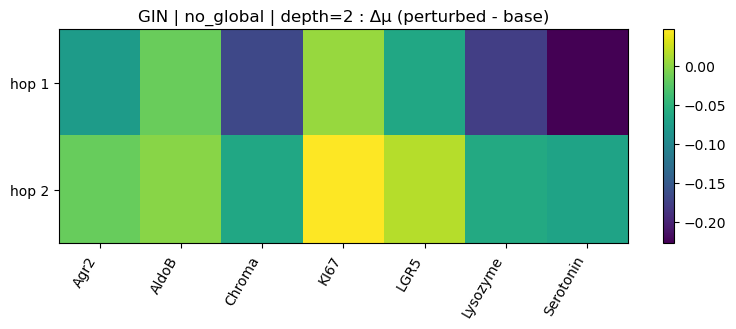

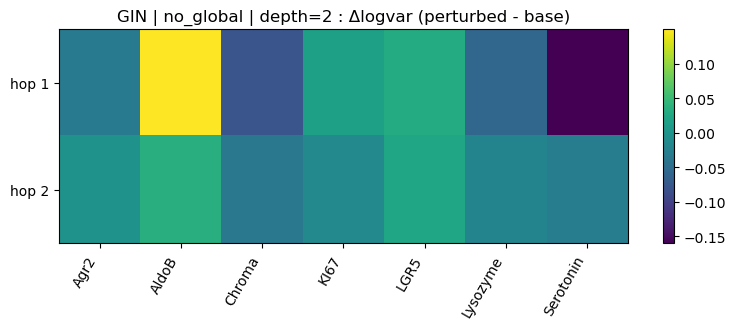

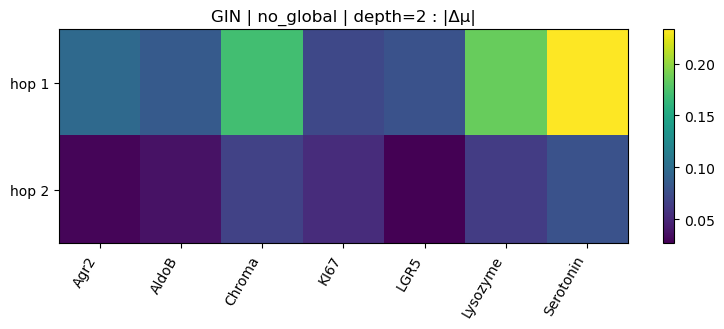

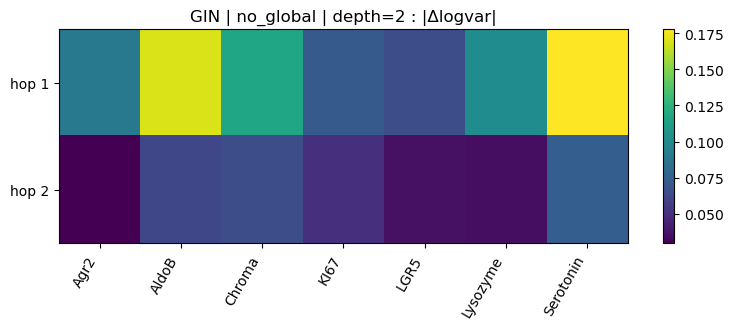

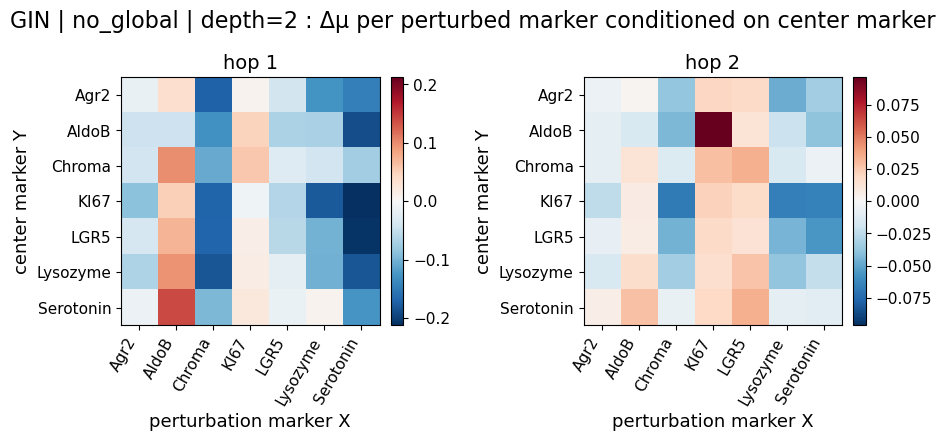

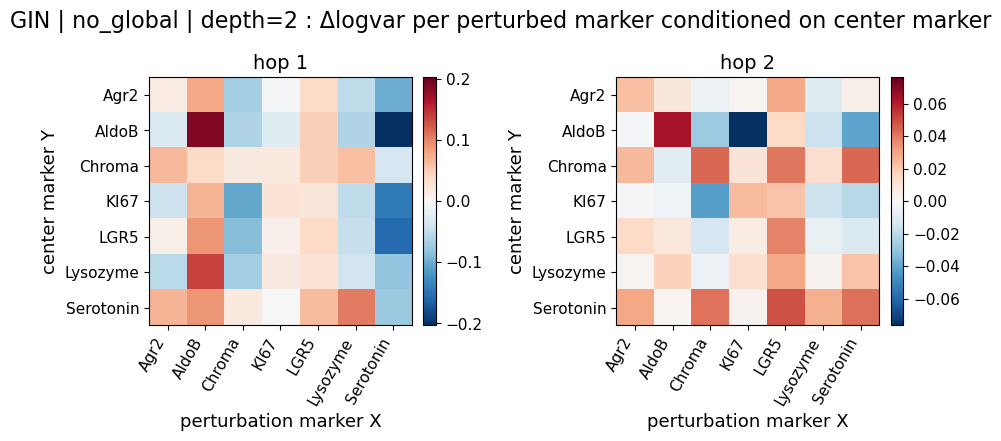

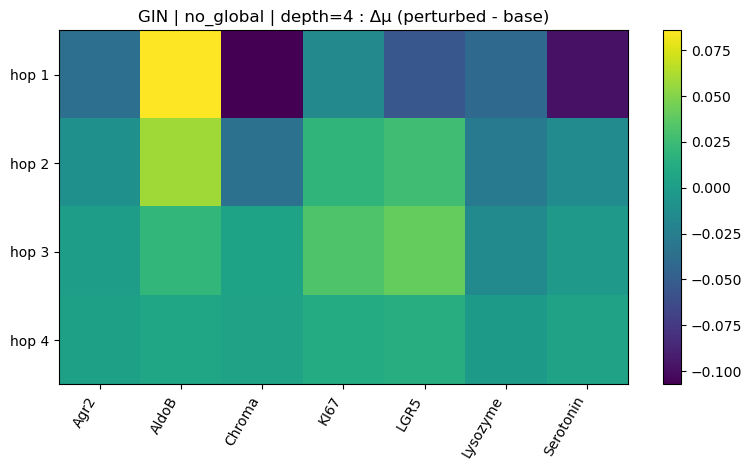

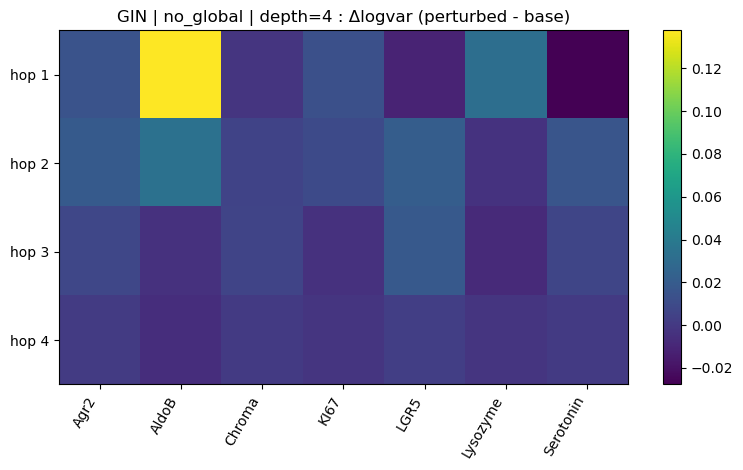

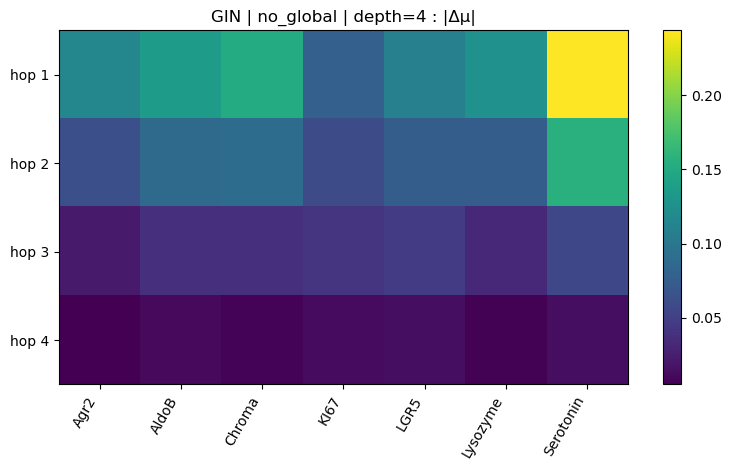

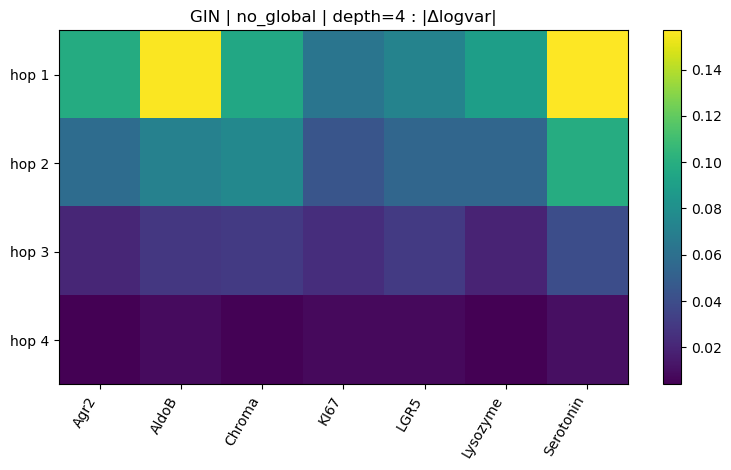

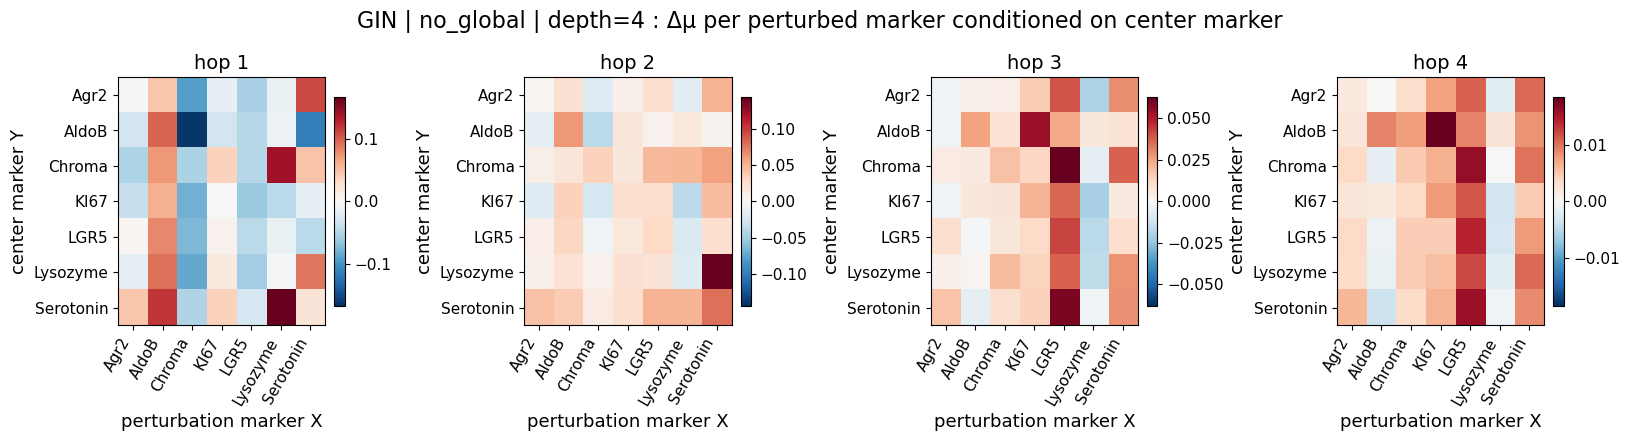

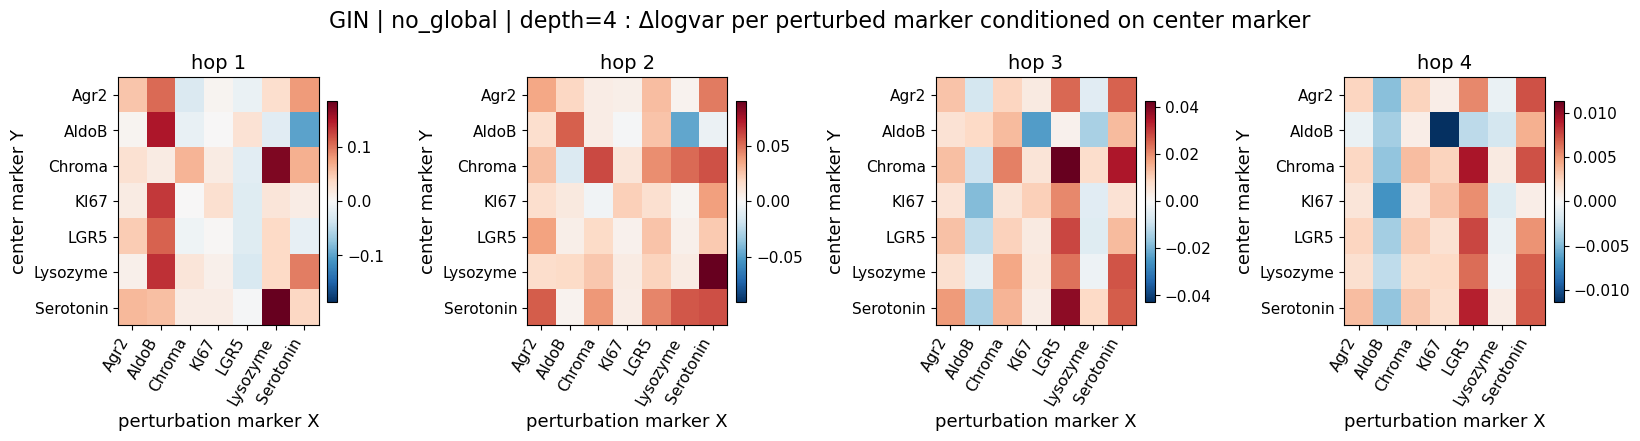

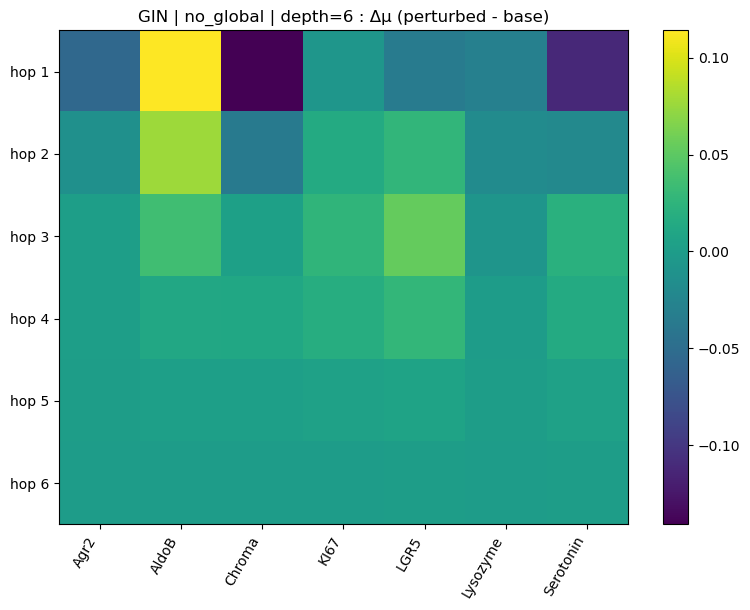

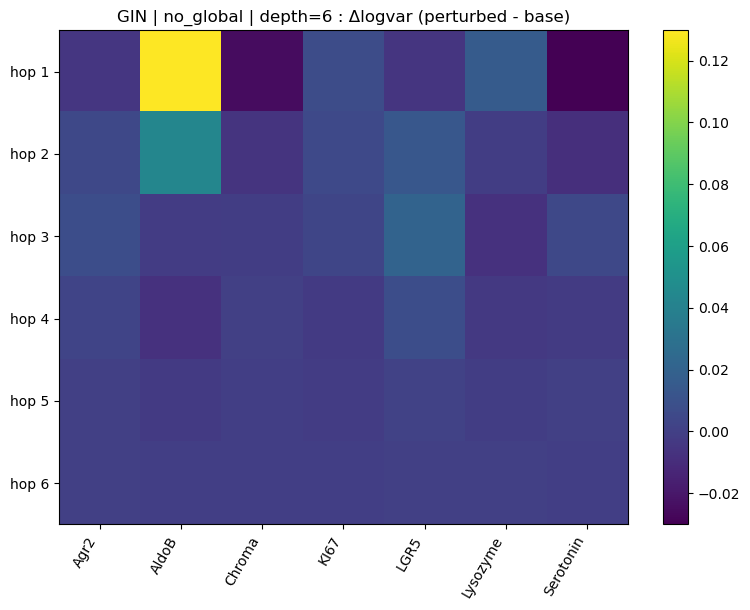

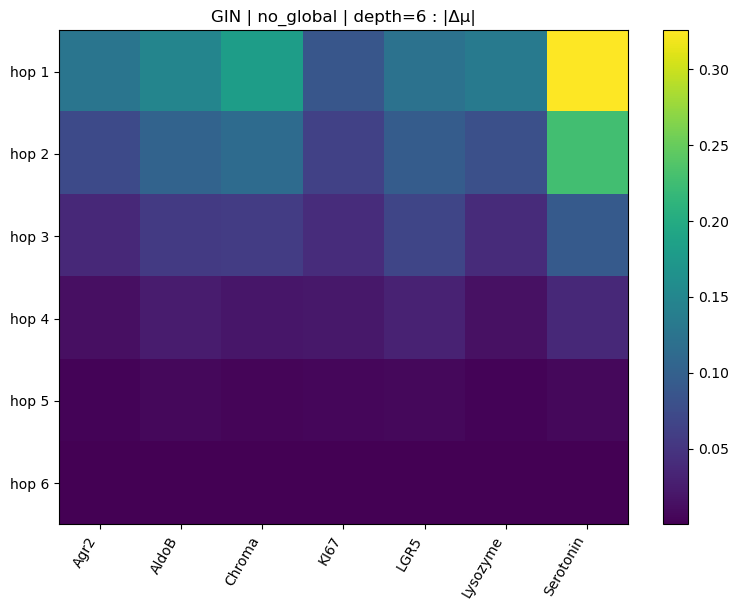

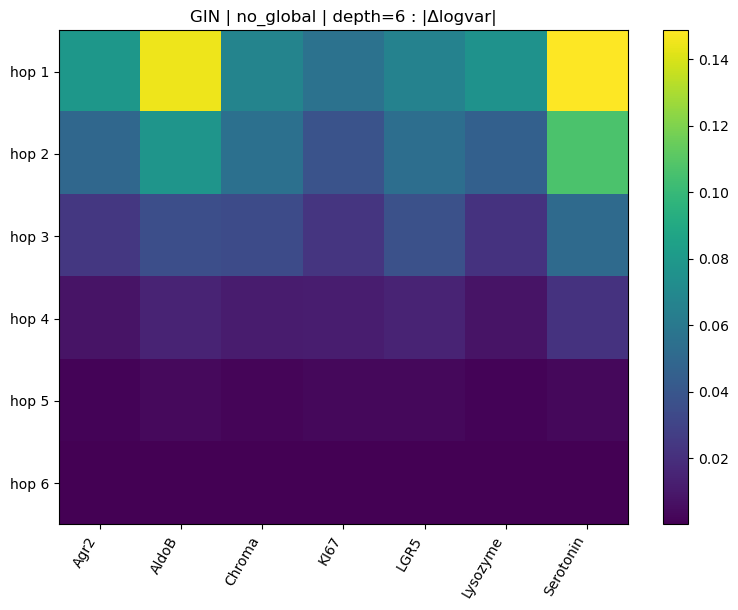

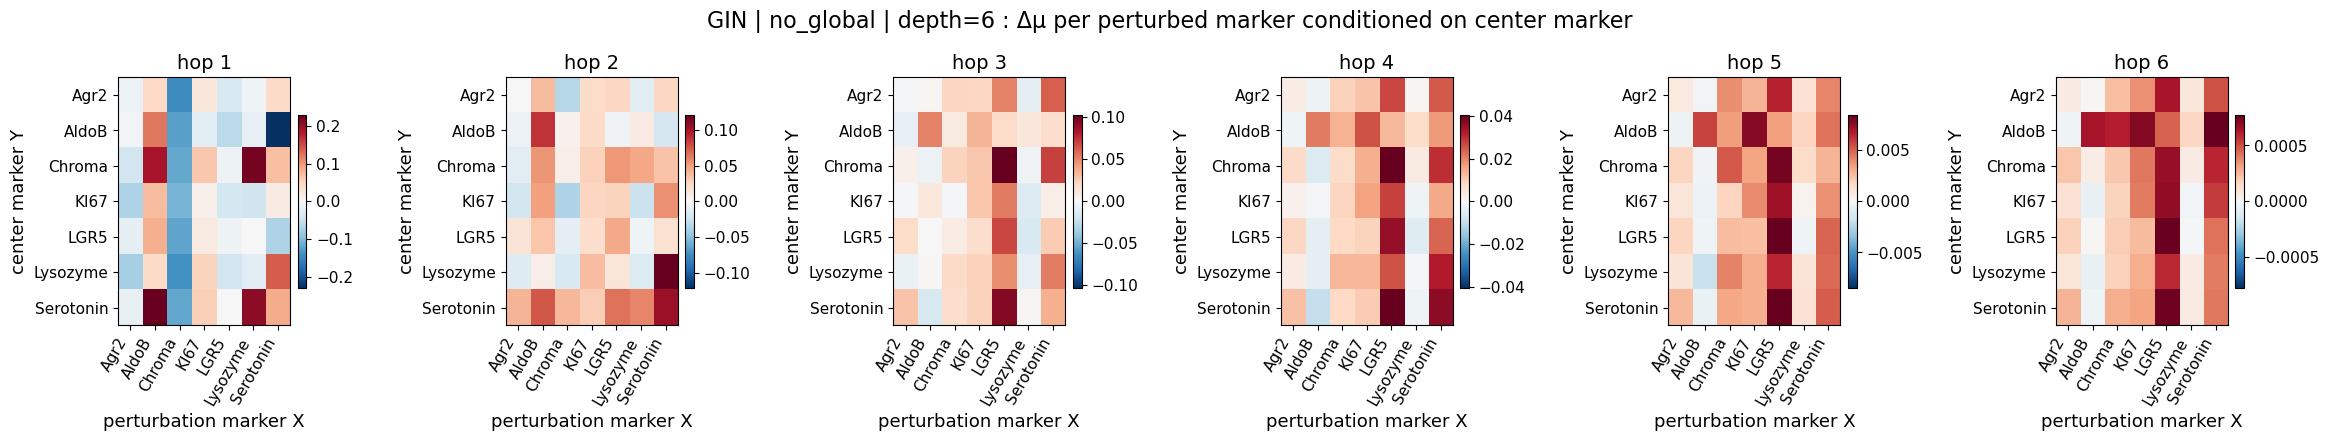

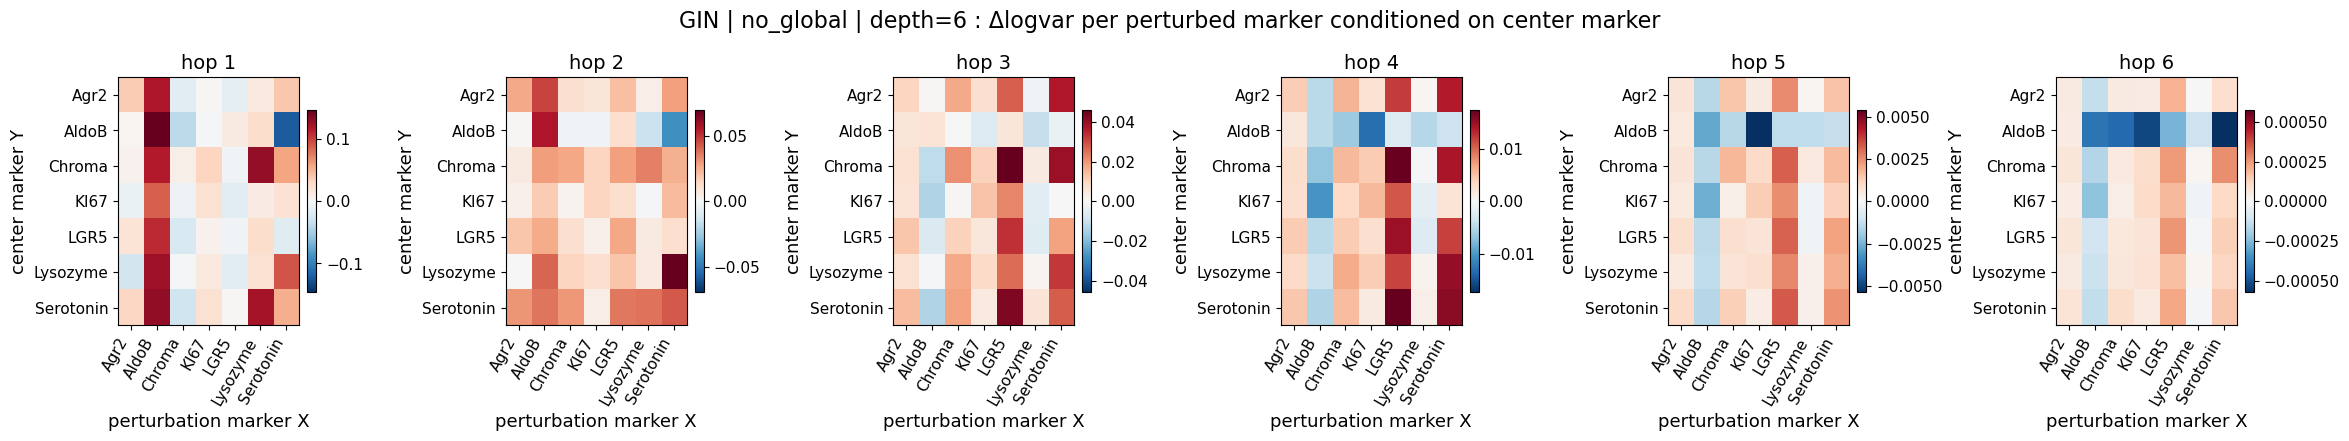

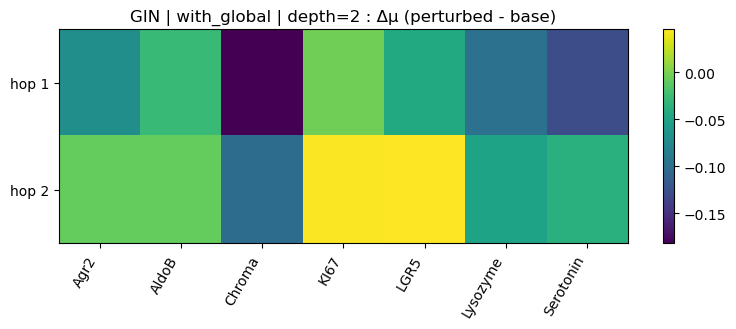

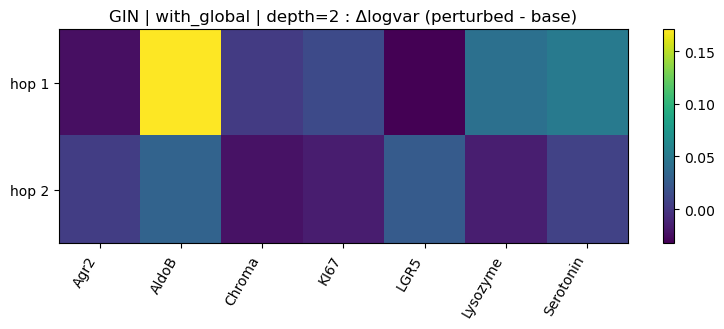

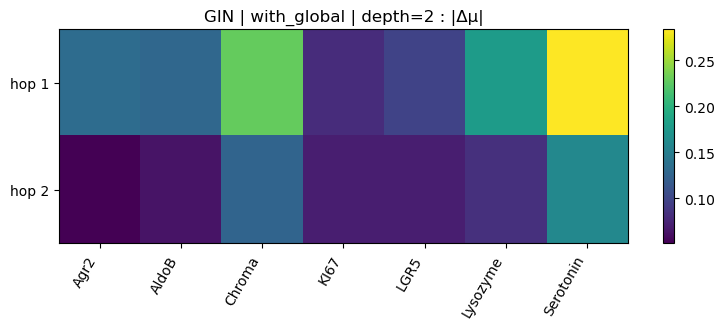

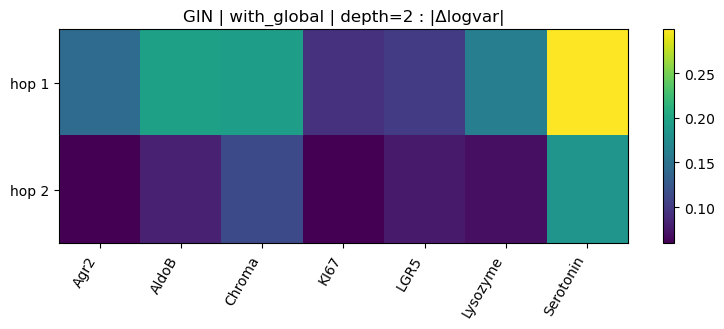

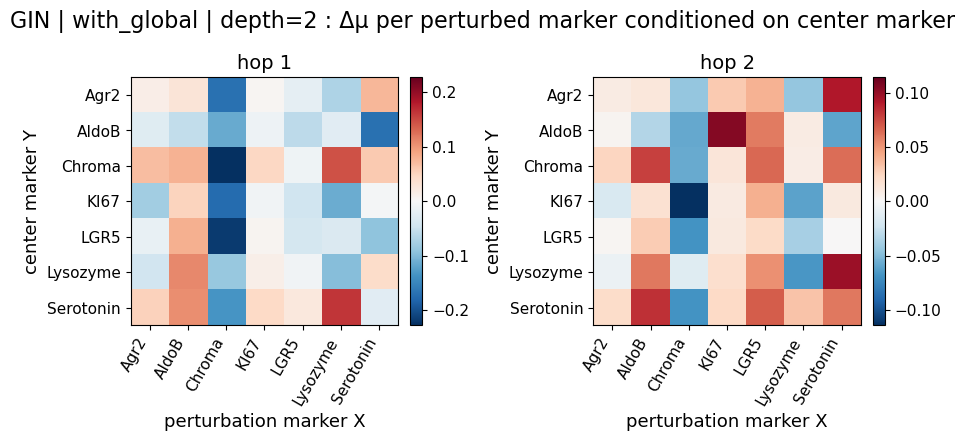

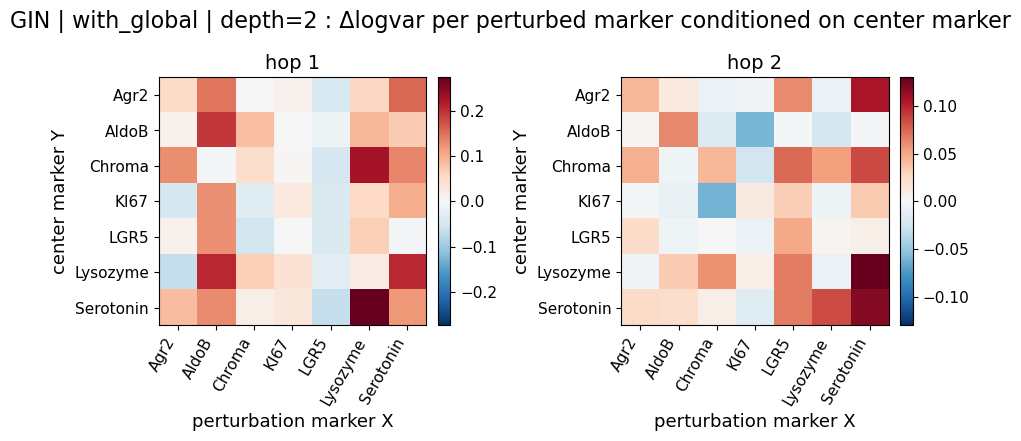

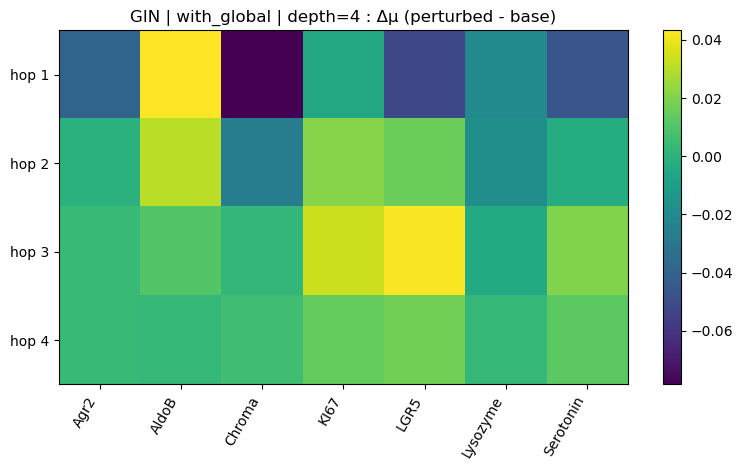

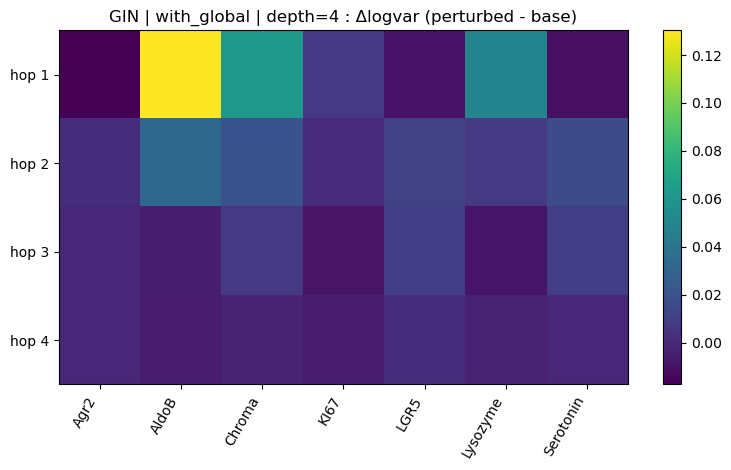

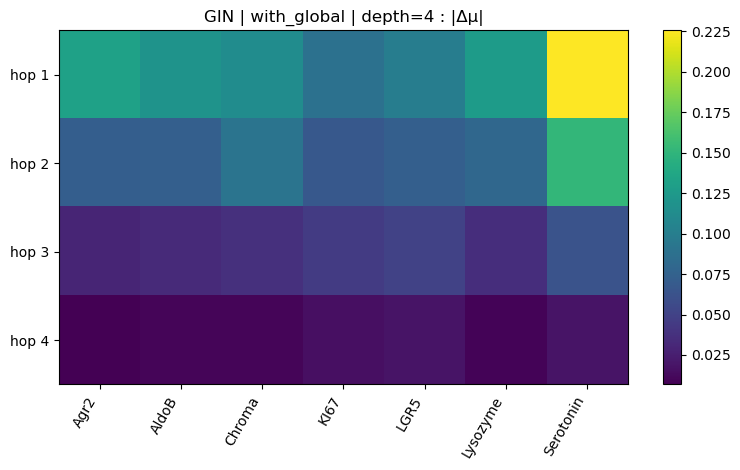

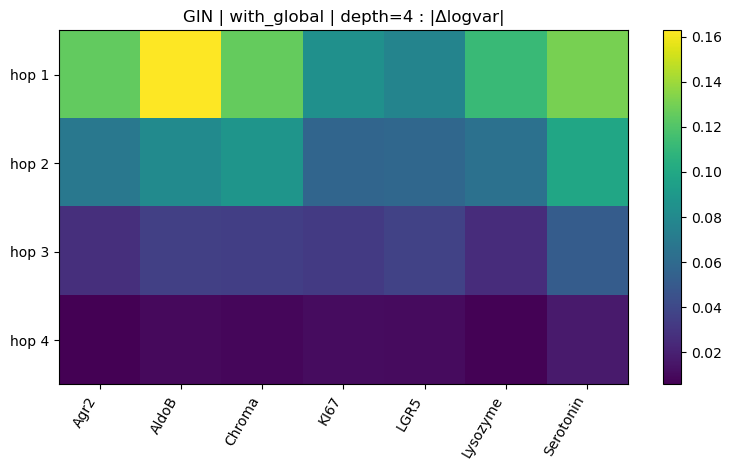

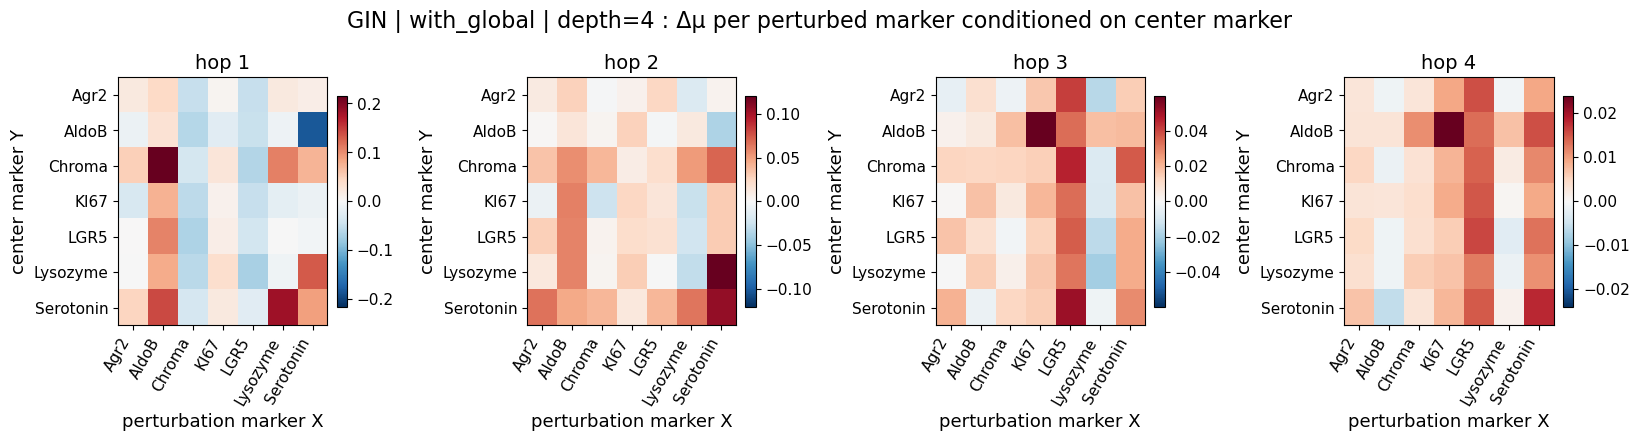

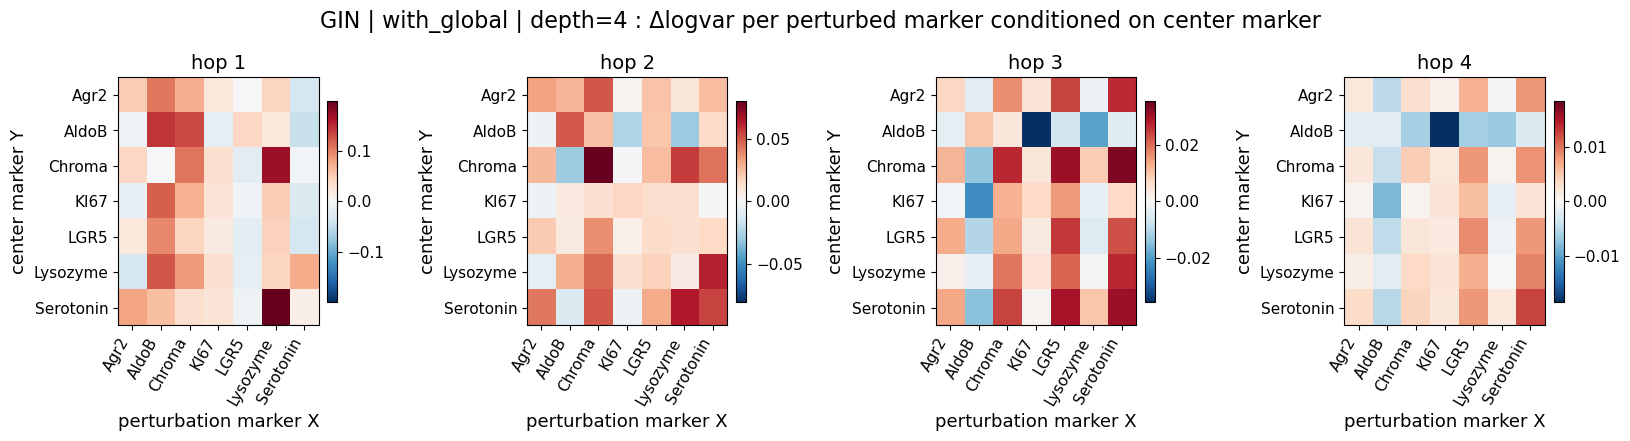

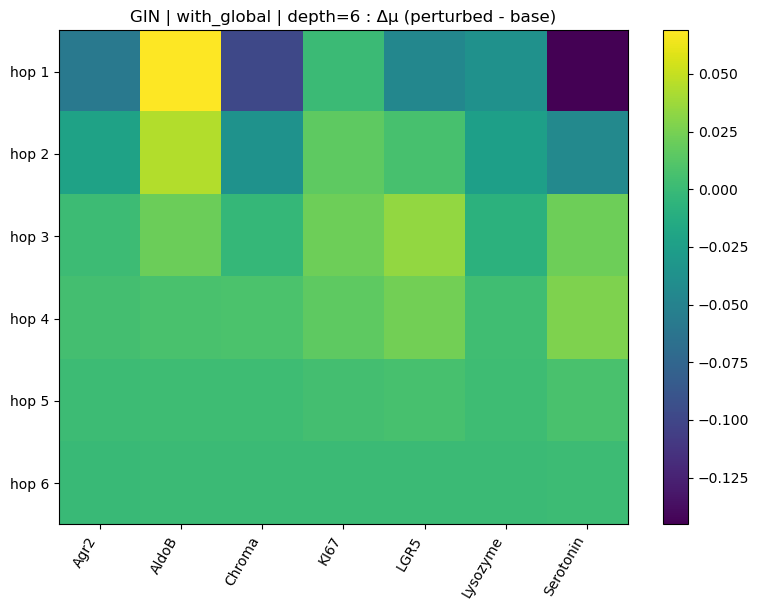

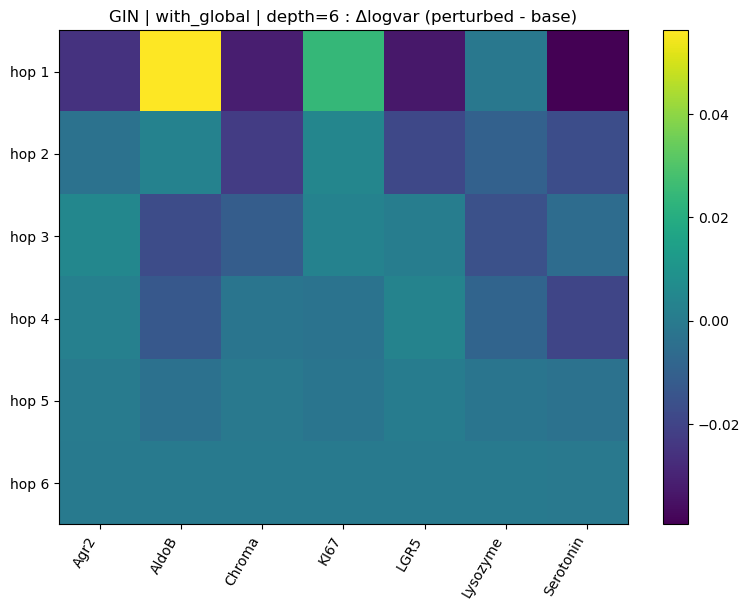

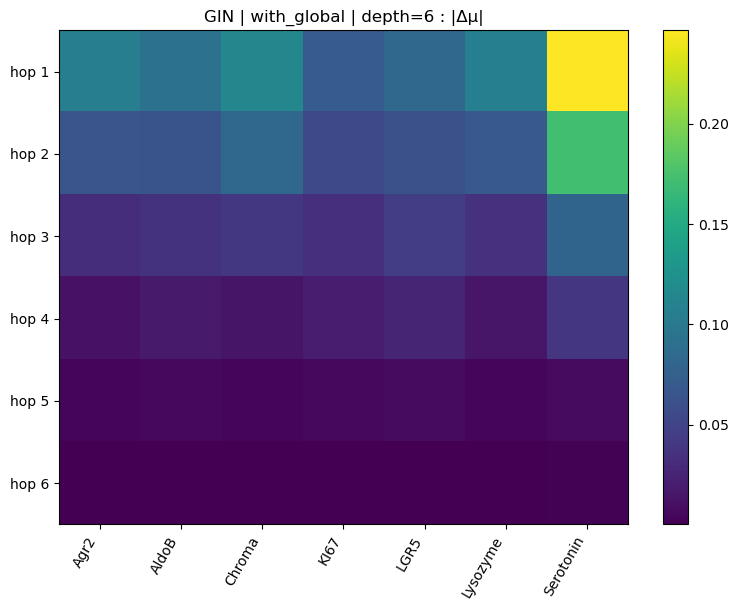

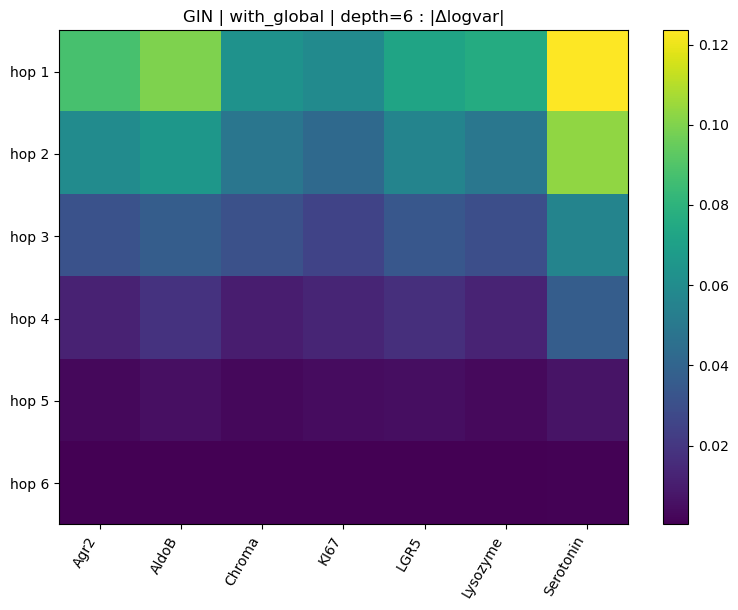

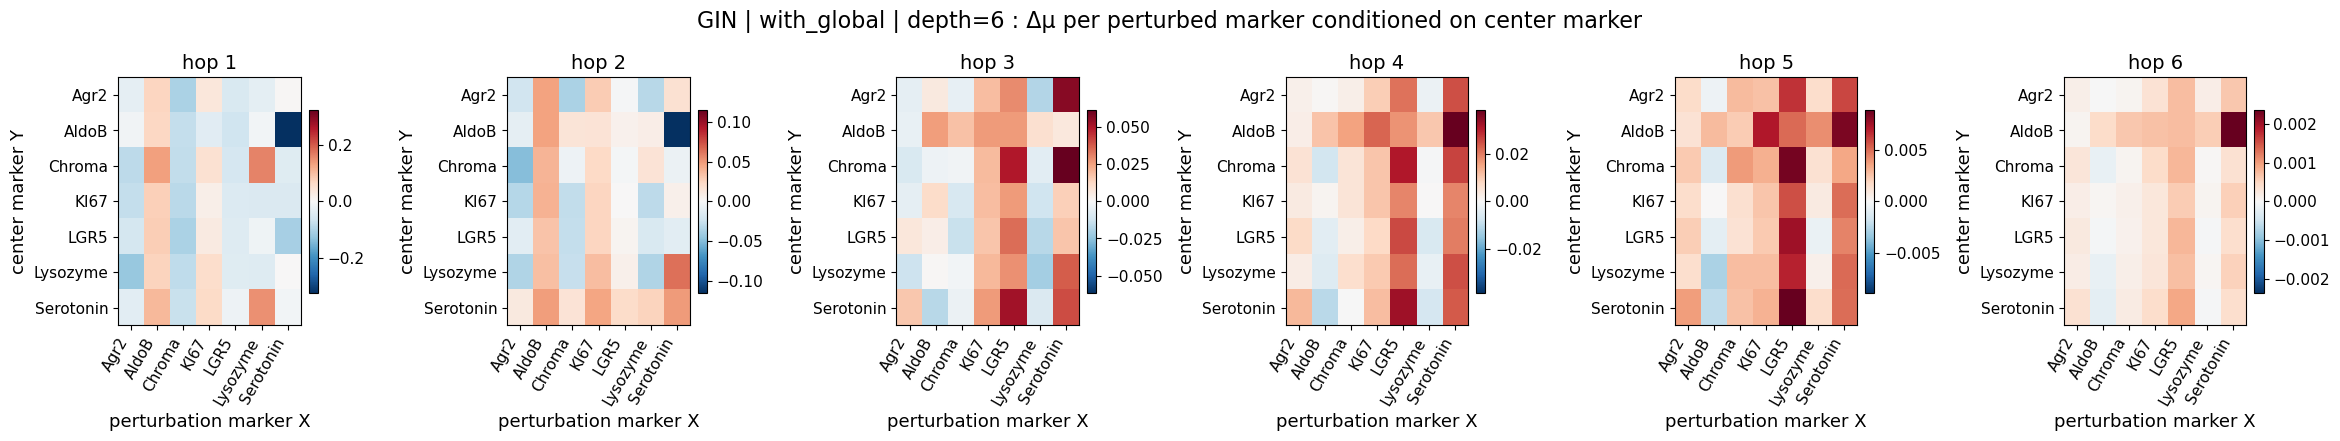

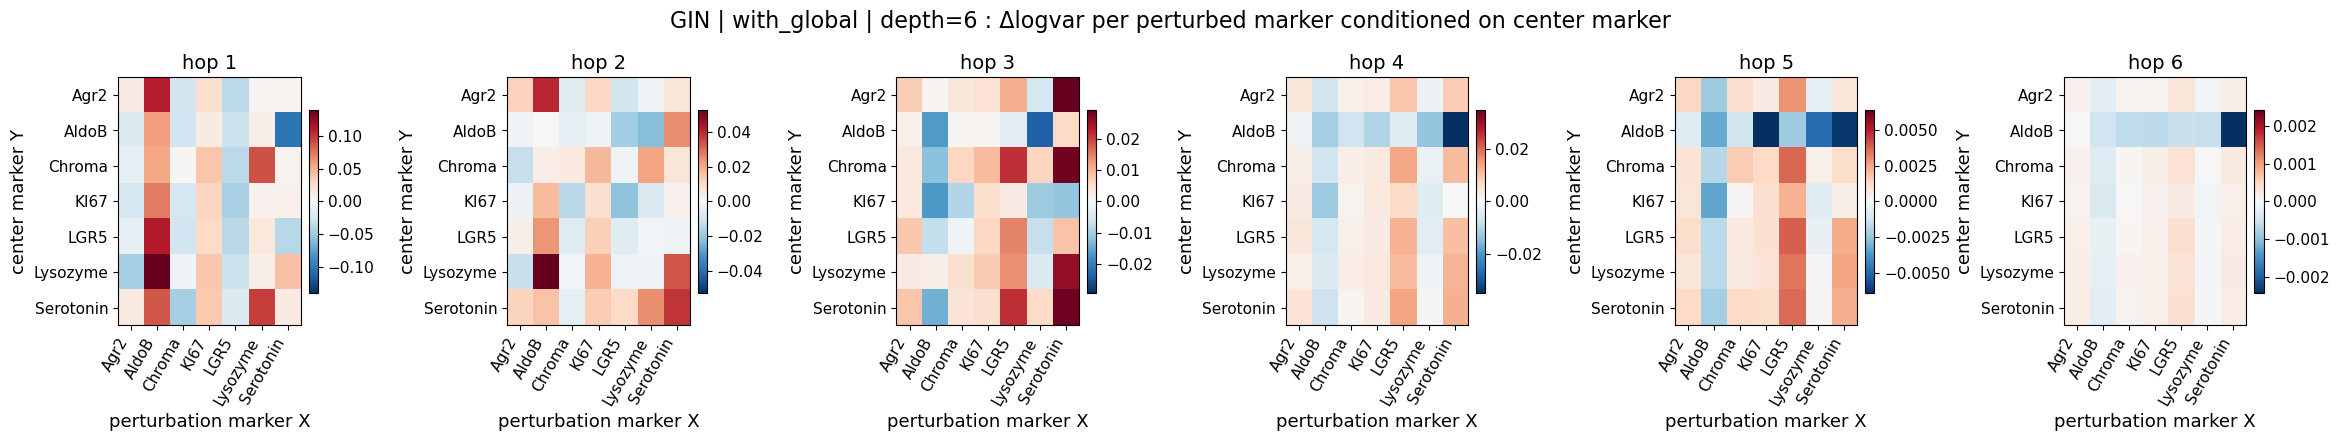

In [32]:

# Visualize all perturbation maps
for family_key in perturbation_results:
    res = perturbation_results[family_key]["result"]
    depth = perturbation_results[family_key]["depth"]

    plot_influence_heatmap(
        res["delta_mu_total"],
        res["hops"],
        res["marker_names"],
        title=f"{family_key} : Δμ (perturbed - base)",
    )

    plot_influence_heatmap(
        res["delta_lv_total"],
        res["hops"],
        res["marker_names"],
        title=f"{family_key} : Δlogvar (perturbed - base)",
    )

    plot_influence_heatmap(
        res["delta_mu_abs_total"],
        res["hops"],
        res["marker_names"],
        title=f"{family_key} : |Δμ|",
    )

    plot_influence_heatmap(
        res["delta_lv_abs_total"],
        res["hops"],
        res["marker_names"],
        title=f"{family_key} : |Δlogvar|",
    )

    plot_influence_center_resolved(
        res["delta_mu_cmarker"],
        res["hops"],
        res["marker_names"],
        title=f"{family_key} : Δμ per perturbed marker conditioned on center marker",
        sort_center=False,
        center_zero=True,
        cmap="RdBu_r",
    )

    plot_influence_center_resolved(
        res["delta_lv_cmarker"],
        res["hops"],
        res["marker_names"],
        title=f"{family_key} : Δlogvar per perturbed marker conditioned on center marker",
        sort_center=False,
        center_zero=True,
        cmap="RdBu_r",
    )


In [33]:

def perturbation_summary_row(family_key, entry):
    res = entry["result"]
    return {
        "family": family_key,
        "variant_name": entry["variant_name"],
        "depth": entry["depth"],
        "n_sampled_subgraphs": entry["n_sampled_subgraphs"],
        "mean_abs_delta_mu": float(np.nanmean(np.abs(res["delta_mu_total"]))),
        "mean_abs_delta_lv": float(np.nanmean(np.abs(res["delta_lv_total"]))),
        "max_abs_delta_mu": float(np.nanmax(np.abs(res["delta_mu_total"]))),
        "max_abs_delta_lv": float(np.nanmax(np.abs(res["delta_lv_total"]))),
    }

summary_rows = [
    perturbation_summary_row(family_key, entry)
    for family_key, entry in perturbation_results.items()
]

summary_rows = sorted(summary_rows, key=lambda d: (d["variant_name"], d["depth"]))
summary_rows


[{'family': 'GIN | no_global | depth=2',
  'variant_name': 'no_global',
  'depth': 2,
  'n_sampled_subgraphs': 2500,
  'mean_abs_delta_mu': 0.07217616735091512,
  'mean_abs_delta_lv': 0.04915279132613687,
  'max_abs_delta_mu': 0.22749718676867156,
  'max_abs_delta_lv': 0.16058490704745054},
 {'family': 'GIN | no_global | depth=4',
  'variant_name': 'no_global',
  'depth': 4,
  'n_sampled_subgraphs': 2500,
  'mean_abs_delta_mu': 0.028339163618546746,
  'mean_abs_delta_lv': 0.0149219779284229,
  'max_abs_delta_mu': 0.10727203109367626,
  'max_abs_delta_lv': 0.13774863509353927},
 {'family': 'GIN | no_global | depth=6',
  'variant_name': 'no_global',
  'depth': 6,
  'n_sampled_subgraphs': 2500,
  'mean_abs_delta_mu': 0.023007058305864407,
  'mean_abs_delta_lv': 0.009076474969929063,
  'max_abs_delta_mu': 0.14073294382385848,
  'max_abs_delta_lv': 0.12982514684741525},
 {'family': 'GIN | with_global | depth=2',
  'variant_name': 'with_global',
  'depth': 2,
  'n_sampled_subgraphs': 2500,
 

In [34]:

def _jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, np.dtype):
        return str(obj)
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(_jsonable(config), f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results_by_experiment, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(_jsonable(meta), f, indent=2)

    print(f"Saved joint experiment -> {save_dir}")


In [35]:

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = RESULTS_ROOT / f"{SAVE_GROUP}_{timestamp}"

joint_config = {
    "save_group": SAVE_GROUP,
    "data_subdir": DATA_SUBDIR,
    "complexity_threshold": COMPLEXITY_THRESHOLD,
    "use_complexity_ge": USE_COMPLEXITY_GE,
    "field_specs": field_specs,
    "val_frac": VAL_FRAC,
    "split_seed": SPLIT_SEED,
    "feature_variants": FEATURE_VARIANTS,
    "depths": DEPTHS,
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "norm": NORM,
    "residual": RESIDUAL,
    "train_config": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "perturbation_config": {
        "max_subgraphs": MAX_SUBGRAPHS,
        "min_center_count": MIN_CENTER_COUNT,
        "min_pair_count": MIN_PAIR_COUNT,
        "subgraph_seed": SUBGRAPH_SEED,
        "perturb_batch_size": PERTURB_BATCH_SIZE,
        "mode": "single",
    },
    "n_train_graphs": len(base_train),
    "n_val_graphs": len(base_val),
    "marker_names": list(marker_names),
}

results_by_experiment = {
    "summary_rows": summary_rows,
    "training_logs": training_logs,
    "prediction_summaries": prediction_summaries,
    "sampling_results": sampling_results,
    "perturbation_results": perturbation_results,
}

save_joint_experiment(
    save_dir=save_dir,
    config=joint_config,
    results_by_experiment=results_by_experiment,
    notes=(
        "Neighborhood perturbation analysis for GINCurvature with and without "
        "global features at depths 2, 4, and 6."
    ),
)


Saved joint experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis_global/gin_perturbation_analysis_20260415_232838
